
# Metacontrol Data Generation Pipeline
### A Didactic Walkthrough of Search Tree Generation and Target Derivation

This notebook demonstrates the modular pipeline for generating chess search trees and computing the associated training targets for:
1. **GNN Pretraining**: Supervised learning of value and WDL heads.
2. **Meta-Control (Planning Head)**: RL-based advantage regression for search termination.

We use the **actual LC0 engine** to provide realistic search statistics, ensuring that our pipeline correctly handles the intricacies of UCI output and perspective-taking.



## Core Concept: The Perspective Shift

In a chess search tree, every level flips the "side to move". This creates a challenge for data consistency:
- **Engine Perspective**: LC0 reports Q-values from the perspective of the **Parent** (the side that just moved).
- **Node Perspective**: We store features from the perspective of the **Child** (the side whose turn it is in that state).

**Our Rule**: `Node_Value = -Engine_Q`. 
This ensures that if White moves to a winning position, the Black child node reflects a negative value (losing), and vice-versa. 

During **Backpropagation**, we flip the value again at each parent level, restoring the original engine intent for the edges while maintaining local perspective consistency for the nodes.



## 1. Environment Setup and Imports
We import the core components from the `metacontrol` package.


In [1]:

import sys
import os
import chess
import random
import torch
import matplotlib.pyplot as plt
from IPython.display import display

# Add src to path
sys.path.append(os.path.abspath("../../"))

from metacontrol.core.tree import SearchTree
from metacontrol.core.schemas import GeneratorConfig
from metacontrol.core.providers import LC0ExpansionProvider
from metacontrol.data.generator import TreeSearch
from metacontrol.data.targets_mc import derive_snapshots
from metacontrol.data.targets_gnn import compute_gnn_targets
from metacontrol.utils.plotting import render_tree, render_gnn_view, plot_advantage_landscape



## 2. The Engine Provider
The `LC0ExpansionProvider` is configured to use the production distilled weights. 
We set `nodes=128` to get a stable signal.


In [2]:

LC0_BIN = "/scratch/gpfs/GRIFFITHS/ysagiv/tools/lc0/build/release/lc0"
LC0_WEIGHTS = "/scratch/gpfs/GRIFFITHS/ysagiv/chess/weights/t1-256x10-distilled-swa-2432500.pb.gz"

# Initialize provider
provider = LC0ExpansionProvider(LC0_BIN, LC0_WEIGHTS, nodes=128)
print("LC0 Provider initialized successfully.")


LC0 Provider initialized successfully.



## 3. Root Selection
We'll use a fixed midgame FEN that allows for clear branching.


Starting Position (Scholar's Mate): r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 4 4


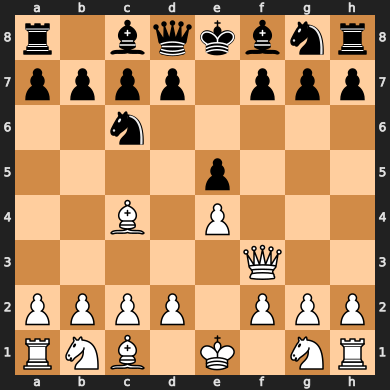

In [3]:

# Scholar's Mate: White to move, Qf7# is winning
root_fen = "r1bqkbnr/pppp1ppp/2n5/4p3/2B1P3/5Q2/PPPP1PPP/RNB1K1NR w KQkq - 4 4"
print(f"Starting Position (Scholar's Mate): {root_fen}")
board = chess.Board(root_fen)
display(board)



## 4. Tree Search (PUCT)
We perform a search with 16 expansions. In this didactic example, we expect the engine to quickly identify `f3f7#` as the winning move and focus its budget there.


Growing search tree...


Tree grown with 524 nodes.


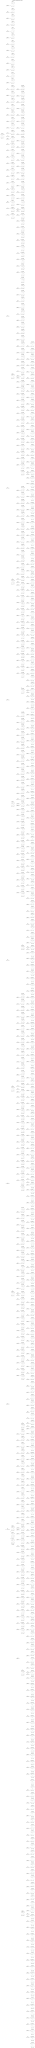

In [4]:

# Configure search: 16 expansions to see the mate prioritization
config = GeneratorConfig(max_nodes=16, max_depth=4, c_puct=1.5)
search = TreeSearch(provider, config)

print("Growing search tree...")
result = search.generate(root_fen)
print(f"Tree grown with {len(result.tree.nodes_by_id)} nodes.")

# Visualize the tree
display(render_tree(result.tree, result.edge_stats, title="Scholar's Mate Search Tree"))



## 5. Meta-Control Advantage (DP)
The **Advantage** tells us how much better the final search result is compared to the root's initial estimate, minus the search cost.


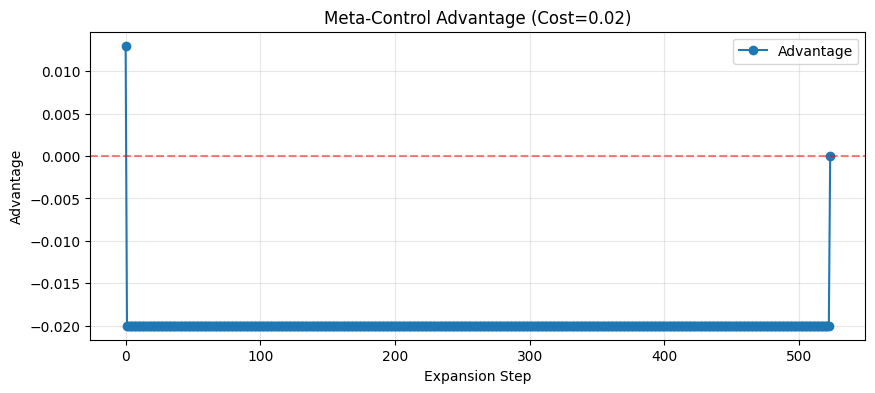

In [5]:

continue_cost = 0.02
snapshots = derive_snapshots(result.tree, result.edge_stats, continue_cost=continue_cost)

# Plot the advantage landscape across search time (expansion count)
plt = plot_advantage_landscape(snapshots, continue_cost=continue_cost)
plt.show()



## 6. GNN Targets
The GNN heads learn to predict the final search outcomes.


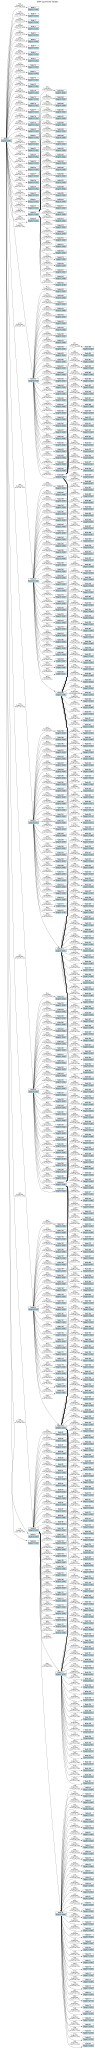

In [6]:

gnn_targets = compute_gnn_targets(result.tree, result.edge_stats)

# Visualize the GNN target view (showing WDL distributions)
display(render_gnn_view(result.tree, gnn_targets, title="GNN Supervised Targets"))
